# LSTM Evaluation — MRR / Recall@k on MS MARCO

Compares three retrieval methods on the **MS MARCO** test set using the shared
`evaluate_ranking` protocol from `src/tfidf_retrieval.py`:

| Method | Description |
|--------|-------------|
| **TF-IDF** | Sparse lexical baseline (sublinear TF, IDF, L2-norm) |
| **BoW** | Bag-of-words cosine baseline (L2-normalized counts) |
| **LSTM** | BiLSTM bi-encoder trained from scratch with InfoNCE |

**Prerequisites:**
- `data/msmarco_pairs/{train,validation,test}.jsonl` (run `scripts/build_msmarco_pairs.py`)
- `checkpoints/lstm_msmarco/last.pt` + `vocab.json` (run `notebooks/train_lstm.ipynb`)

In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"project root: {ROOT}")

project root: /Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP


## 1  Load MS MARCO data

In [2]:
from src.tfidf_retrieval import (
    build_unique_corpus,
    evaluate_ranking,
    group_queries_by_id,
    load_jsonl,
)

DATA_DIR = ROOT / "data" / "msmarco_pairs"
train_p   = DATA_DIR / "train.jsonl"
val_p     = DATA_DIR / "validation.jsonl"
test_p    = DATA_DIR / "test.jsonl"

for p in (train_p, val_p, test_p):
    if not p.exists():
        raise FileNotFoundError(
            f"{p} not found. Run `python scripts/build_msmarco_pairs.py` first."
        )

corpus = build_unique_corpus([train_p, val_p, test_p])
test_rows = load_jsonl(test_p)
gold_by_qid, query_text = group_queries_by_id(test_rows)
qids = sorted(gold_by_qid.keys())

print(f"corpus size : {len(corpus):,} unique passages")
print(f"test queries: {len(qids):,} distinct query IDs")

corpus size : 105,793 unique passages
test queries: 9,345 distinct query IDs


## 2  TF-IDF baseline

In [3]:
from src.tfidf_retrieval import TfidfSearchEngine

KS = [1, 5, 10, 50, 100]

tfidf_engine = TfidfSearchEngine.fit(corpus)
tfidf_metrics = evaluate_ranking(tfidf_engine, gold_by_qid, query_text, KS)
print("TF-IDF:", tfidf_metrics)

TF-IDF: {'n_queries': 9345, 'mrr': 0.5182755077220351, 'recall@1': 0.4036383092562868, 'recall@5': 0.6574638844301766, 'recall@10': 0.7421080791867308, 'recall@50': 0.8772605671482075, 'recall@100': 0.9077581594435526}


## 3  BoW baseline

In [4]:
from src.bow_retrieval import BowSearchEngine

bow_engine = BowSearchEngine.fit(corpus)
bow_metrics = evaluate_ranking(bow_engine, gold_by_qid, query_text, KS)
print("BoW:", bow_metrics)

BoW: {'n_queries': 9345, 'mrr': 0.197226474862918, 'recall@1': 0.134617442482611, 'recall@5': 0.2574638844301766, 'recall@10': 0.3196361690743713, 'recall@50': 0.4642054574638844, 'recall@100': 0.5278758694489032}


## 4  LSTM bi-encoder

In [5]:
import numpy as np
import torch
from tqdm.auto import tqdm

from src.lstm_encoder import LSTMEncoder
from src.torch_device import pick_torch_device
from src.vocab import Vocabulary

CKPT_DIR   = ROOT / "checkpoints" / "lstm_msmarco"
CKPT_PATH  = CKPT_DIR / "last.pt"
VOCAB_PATH = CKPT_DIR / "vocab.json"

for p in (CKPT_PATH, VOCAB_PATH):
    if not p.exists():
        raise FileNotFoundError(
            f"{p} not found. Run `notebooks/train_lstm.ipynb` first."
        )

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
vocab = Vocabulary.load(VOCAB_PATH)
device = pick_torch_device("auto")

model = LSTMEncoder(
    vocab_size  = ckpt["vocab_size"],
    embed_dim   = ckpt.get("embed_dim",   300),
    hidden_dim  = ckpt.get("hidden_dim",  256),
    num_layers  = ckpt.get("num_layers",  1),
    dropout     = ckpt.get("dropout",     0.1),
    proj_dim    = ckpt.get("proj_dim",    256),
)
model.load_state_dict(ckpt["encoder_state_dict"])
model.to(device)
model.eval()

MAX_DOC_TOKENS   = int(ckpt.get("max_doc_tokens",   128))
MAX_QUERY_TOKENS = int(ckpt.get("max_query_tokens",  32))
ENCODE_BATCH     = 256

print(f"device      : {device}")
print(f"vocab_size  : {len(vocab):,}")
print(f"epoch loaded: {ckpt.get('epoch', '?')}")
print(f"max_doc_tok : {MAX_DOC_TOKENS}  max_query_tok: {MAX_QUERY_TOKENS}")

/Users/lukalodia/Desktop/NLP Project/Vector_Search_NLP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device      : mps
vocab_size  : 50,002
epoch loaded: 15
max_doc_tok : 128  max_query_tok: 32


In [6]:
# Encode the full corpus with the LSTM encoder
def encode_corpus_lstm(
    model: LSTMEncoder,
    vocab: Vocabulary,
    texts: list[str],
    device: torch.device,
    batch_size: int,
    max_length: int,
) -> np.ndarray:
    model.eval()
    out: list[np.ndarray] = []
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size), desc="Encode corpus", unit="batch"):
            batch = vocab.encode_batch(texts[start : start + batch_size], max_length=max_length)
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            emb  = model.encode(ids, mask).detach().cpu().numpy().astype(np.float32)
            out.append(emb)
    return np.concatenate(out, axis=0) if out else np.zeros((0, model.out_dim), dtype=np.float32)


doc_emb = encode_corpus_lstm(model, vocab, corpus, device, batch_size=ENCODE_BATCH, max_length=MAX_DOC_TOKENS)
print(f"doc_emb shape: {doc_emb.shape}")

Encode corpus: 100%|██████████| 414/414 [01:26<00:00,  4.77batch/s]


doc_emb shape: (105793, 256)


In [7]:
# Wrap in a search engine that implements the gold_rank / rank interface
class LSTMSearchEngine:
    """Dense search engine backed by LSTMEncoder + Vocabulary."""

    def __init__(
        self,
        model: LSTMEncoder,
        vocab: Vocabulary,
        corpus: list[str],
        doc_embeddings: np.ndarray,
        device: torch.device,
        max_query_length: int = 32,
    ) -> None:
        self.model = model
        self.vocab = vocab
        self.corpus = corpus
        self.doc_embeddings = doc_embeddings
        self.device = device
        self.max_query_length = max_query_length
        self._text_to_index = {t: i for i, t in enumerate(corpus)}

    def rank(self, query: str) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            batch = self.vocab.encode_batch([query], max_length=self.max_query_length)
            ids  = batch["input_ids"].to(self.device)
            mask = batch["attention_mask"].to(self.device)
            q    = self.model.encode(ids, mask).detach().cpu().numpy().astype(np.float32)
        return (self.doc_embeddings @ q.T).ravel()

    def gold_rank(self, query: str, gold_docs: set[str]) -> int | None:
        scores  = self.rank(query)
        indices = [self._text_to_index[d] for d in gold_docs if d in self._text_to_index]
        if not indices:
            return None
        n       = scores.shape[0]
        idx_all = np.arange(n)
        best: int | None = None
        for g in indices:
            s = scores[g]
            r = int(np.sum(scores > s) + np.sum((scores == s) & (idx_all < g)))
            if best is None or r < best:
                best = r
        return best


lstm_engine  = LSTMSearchEngine(model, vocab, corpus, doc_emb, device, max_query_length=MAX_QUERY_TOKENS)
lstm_metrics = evaluate_ranking(lstm_engine, gold_by_qid, query_text, KS)
print("LSTM:", lstm_metrics)

LSTM: {'n_queries': 9345, 'mrr': 0.39835889277669856, 'recall@1': 0.28892455858747995, 'recall@5': 0.5237025147137506, 'recall@10': 0.6193686463349385, 'recall@50': 0.7838416265382557, 'recall@100': 0.8300695559122525}


## 5  Side-by-side comparison

In [8]:
import pandas as pd

rows_data = []
for label, m in [("TF-IDF", tfidf_metrics), ("BoW", bow_metrics), ("LSTM", lstm_metrics)]:
    row = {"method": label, "n_queries": m["n_queries"], "MRR": round(m["mrr"], 4)}
    for k in KS:
        row[f"R@{k}"] = round(m[f"recall@{k}"], 4)
    rows_data.append(row)

df = pd.DataFrame(rows_data).set_index("method")
print(df.to_string())
df

        n_queries     MRR     R@1     R@5    R@10    R@50   R@100
method                                                           
TF-IDF       9345  0.5183  0.4036  0.6575  0.7421  0.8773  0.9078
BoW          9345  0.1972  0.1346  0.2575  0.3196  0.4642  0.5279
LSTM         9345  0.3984  0.2889  0.5237  0.6194  0.7838  0.8301


,n_queries,MRR,R@1,R@5,R@10,R@50,R@100
method,,,,,,,
TF-IDF,9345,0.5183,0.4036,0.6575,0.7421,0.8773,0.9078
BoW,9345,0.1972,0.1346,0.2575,0.3196,0.4642,0.5279
LSTM,9345,0.3984,0.2889,0.5237,0.6194,0.7838,0.8301


## 6  Bar chart — MRR & Recall@k

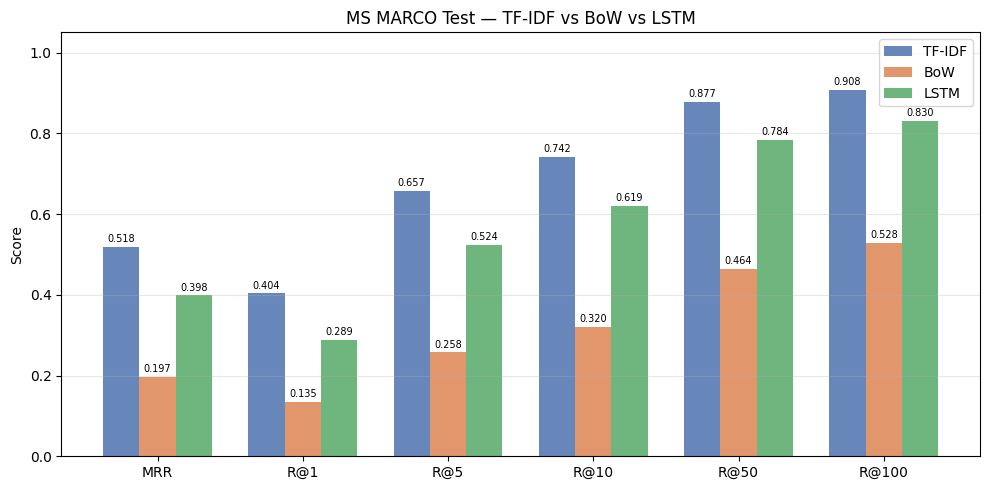

saved → checkpoints/lstm_msmarco/eval_comparison.png


In [9]:
import matplotlib.pyplot as plt

metrics_to_plot = ["MRR"] + [f"R@{k}" for k in KS]
x = np.arange(len(metrics_to_plot))
width = 0.25
methods = ["TF-IDF", "BoW", "LSTM"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (method, color) in enumerate(zip(methods, colors)):
    vals = [df.loc[method, m] for m in metrics_to_plot]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=method, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_title("MS MARCO Test — TF-IDF vs BoW vs LSTM")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "checkpoints" / "lstm_msmarco" / "eval_comparison.png", dpi=150)
plt.show()
print("saved → checkpoints/lstm_msmarco/eval_comparison.png")

## 7  Qualitative spot-check

In [10]:
DEMO_QUERIES = [
    "what causes a cold",
    "how does photosynthesis work",
    "what is the speed of light",
]

TOP_K = 3

for q in DEMO_QUERIES:
    print(f"\n{'='*70}")
    print(f"QUERY: {q!r}")
    for label, engine in [("TF-IDF", tfidf_engine), ("BoW", bow_engine), ("LSTM", lstm_engine)]:
        scores = engine.rank(q)
        order  = np.argsort(-scores)[:TOP_K]
        print(f"\n  [{label}]")
        for rank, idx in enumerate(order, 1):
            snippet = " ".join(corpus[int(idx)].split())[:200]
            print(f"    #{rank} score={scores[int(idx)]:.4f}  {snippet}...")


QUERY: 'what causes a cold'

  [TF-IDF]
    #1 score=0.3066  By Patsy Hamilton | Cold | Rating: Many people still think that bacteria causes the common cold and this is probably the reason that people still visit the doctor asking for antibiotics. Actually, peo...
    #2 score=0.2676  No. Brain freeze is a headache most commonly associated with the quick consumption of cold substances, such as ice cream. When the cold substance comes into contact with you … r palate or the roof of ...
    #3 score=0.2624  Causes. Cold sores are caused by certain strains of the herpes simplex virus (HSV). HSV-1 usually causes cold sores. HSV-2 is usually responsible for genital herpes. However, either type can cause sor...

  [BoW]
    #1 score=0.4345  Causes of Similar Symptoms to Extreme tiredness. Research the causes of these symptoms that are similar to, or related to, the symptom Extreme tiredness: 1 Fatigue (3235 causes). 2 Chronic fatigue syn...
    #2 score=0.4255  Research the causes of these 